# DS301 Lab 9 - Breast Cancer Classification

**Student Name:** Sasinan Khumgrad

**Student ID:** 2025016591  

## Lab objective
This notebook builds and optimizes four classification models:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Support Vector Machine (SVM)

Each model is trained **without SMOTE** and **with SMOTE** using pipelines and `GridSearchCV`. The models are compared using ROC-AUC and additional classification metrics. Malignant diagnosis is treated as the positive class because failing to identify a malignant case is especially important in this problem.

> This analysis is for educational purposes and is not a clinical diagnostic system.

## 1. Import libraries

The analysis uses scikit-learn for modeling and imbalanced-learn for SMOTE. A fixed random state is used so the results are reproducible.

In [1]:
from pathlib import Path
import json
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

## 2. Load and inspect the dataset

The code checks several possible filenames so the notebook can run whether the CSV keeps its original name or the uploaded filename.

In [2]:
candidate_paths = [
    Path("Breast_Cancer_Data_Set.csv")
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Breast cancer CSV not found. Place Breast_Cancer_Data_Set.csv in the same folder as this notebook."
    )

raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded file: {DATA_PATH}")
print(f"Raw dataset shape: {raw_df.shape}")
display(raw_df.head())

Loaded file: Breast_Cancer_Data_Set.csv
Raw dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,NaN


In [3]:
print("Column data types:")
display(raw_df.dtypes.to_frame("dtype").T)

print("\nMissing values by column (only columns with missing values):")
missing = raw_df.isna().sum()
display(missing[missing > 0].to_frame("missing_count"))

print(f"Duplicate rows: {raw_df.duplicated().sum()}")
print("\nOriginal diagnosis distribution:")
display(
    pd.DataFrame({
        "Count": raw_df["diagnosis"].value_counts(),
        "Percentage": raw_df["diagnosis"].value_counts(normalize=True).mul(100).round(2),
    })
)

Column data types:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
dtype,int64,object,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64



Missing values by column (only columns with missing values):


,missing_count
Unnamed: 32,569


Duplicate rows: 0

Original diagnosis distribution:


,Count,Percentage
diagnosis,,
B,357,62.74
M,212,37.26


## 3. Data preparation and rationale

### Redundant columns
- `id` is removed because it is only a record identifier. It does not describe the tumor and could introduce meaningless patterns.
- `Unnamed: 32` is removed because it is completely empty.

### Target encoding
The categorical diagnosis is converted to numeric form:
- Benign (`B`) = 0
- Malignant (`M`) = 1

This makes malignant the positive class for precision, recall, F1-score, and ROC-AUC.

### Scaling
Standardization is applied to Logistic Regression, KNN, and SVM because these methods are affected by feature magnitudes. The dataset contains measurements on very different scales, such as area and smoothness. Decision Trees split one feature at a time and therefore do not require scaling.

### SMOTE placement
For scale-sensitive models, the pipeline order is **StandardScaler -> SMOTE -> model**. This allows SMOTE's nearest-neighbor calculations to occur in standardized feature space. SMOTE remains inside the pipeline so it is applied only to training folds during cross-validation and never to the validation or test data.

In [4]:
df = raw_df.copy()
columns_to_drop = [column for column in ["id", "Unnamed: 32"] if column in df.columns]
df = df.drop(columns=columns_to_drop)

df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

if df["diagnosis"].isna().any():
    raise ValueError("Unexpected diagnosis label found. Expected only B and M.")

X = df.drop(columns="diagnosis")
y = df["diagnosis"]

print(f"Dropped columns: {columns_to_drop}")
print(f"Clean dataset shape: {df.shape}")
print(f"Number of predictor features: {X.shape[1]}")
print(f"Total missing values after cleaning: {df.isna().sum().sum()}")

Dropped columns: ['id', 'Unnamed: 32']
Clean dataset shape: (569, 31)
Number of predictor features: 30
Total missing values after cleaning: 0


## 4. Stratified train-test split

An 80/20 split is used. Stratification preserves the benign-to-malignant ratio in both subsets. The test set is held out and is not used by `GridSearchCV`.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "Training": y_train.value_counts().sort_index(),
    "Testing": y_test.value_counts().sort_index(),
}, index=[0, 1])
split_summary.index = ["Benign (0)", "Malignant (1)"]

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}")
display(split_summary)

Training feature shape: (455, 30)
Testing feature shape: (114, 30)


,Training,Testing
Benign (0),285,72
Malignant (1),170,42


## 5. Define pipelines and hyperparameter grids

Five-fold stratified cross-validation is used. `GridSearchCV` selects the hyperparameters with the highest mean validation ROC-AUC.

The grids are intentionally broad enough to compare meaningful model settings while remaining practical for this dataset.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_specs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
        "scale": True,
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__penalty": ["l1", "l2"],
            "model__class_weight": [None, "balanced"],
        },
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "scale": True,
        "param_grid": {
            "model__n_neighbors": [3, 5, 7, 11, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "scale": False,
        "param_grid": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [None, 3, 5],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__max_features": [None],
            "model__class_weight": [None, "balanced"],
        },
    },
    "SVM": {
        "estimator": SVC(random_state=RANDOM_STATE),
        "scale": True,
        "param_grid": [
            {
                "model__kernel": ["linear"],
                "model__C": [0.01, 0.1, 1, 10],
                "model__class_weight": [None, "balanced"],
            },
            {
                "model__kernel": ["rbf"],
                "model__C": [0.1, 1, 10],
                "model__gamma": ["scale", 0.01, 0.1],
                "model__class_weight": [None, "balanced"],
            },
        ],
    },
}


def build_pipeline(specification, use_smote=False):
    # Create a leakage-safe pipeline for one model and scenario.
    steps = []

    if specification["scale"]:
        steps.append(("scaler", StandardScaler()))

    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))

    steps.append(("model", specification["estimator"]))

    if use_smote:
        return ImbPipeline(steps)
    return SkPipeline(steps)


def positive_class_scores(estimator, features):
    # Return continuous scores used for ROC-AUC and ROC curves.
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(features)[:, 1]
    return estimator.decision_function(features)

## 6. Tune and evaluate all eight model configurations

For every model, the best cross-validated pipeline is refitted on the complete training set and evaluated once on the held-out test set. In addition to ROC-AUC, the table includes malignant precision, malignant recall/sensitivity, specificity, F1-score, and confusion-matrix counts.

In [7]:
results = []
best_estimators = {}
roc_data = {}
classification_reports = {}

start_time = time.time()

for use_smote in [False, True]:
    scenario = "With SMOTE" if use_smote else "Without SMOTE"
    print(f"\n{'=' * 70}\n{scenario}\n{'=' * 70}")

    for model_name, specification in model_specs.items():
        print(f"Tuning {model_name}...")

        pipeline = build_pipeline(specification, use_smote=use_smote)
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=specification["param_grid"],
            scoring="roc_auc",
            cv=cv,
            n_jobs=1,
            refit=True,
            return_train_score=False,
            error_score="raise",
        )
        search.fit(X_train, y_train)

        y_pred = search.predict(X_test)
        y_score = positive_class_scores(search.best_estimator_, X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        test_auc = roc_auc_score(y_test, y_score)
        fpr, tpr, _ = roc_curve(y_test, y_score)

        key = f"{scenario} - {model_name}"
        best_estimators[key] = search.best_estimator_
        roc_data[key] = {"fpr": fpr, "tpr": tpr, "auc": test_auc}
        classification_reports[key] = classification_report(
            y_test,
            y_pred,
            target_names=["Benign", "Malignant"],
            output_dict=True,
            zero_division=0,
        )

        results.append({
            "Scenario": scenario,
            "Model": model_name,
            "Best CV ROC-AUC": search.best_score_,
            "Test ROC-AUC": test_auc,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (Malignant)": precision_score(y_test, y_pred, zero_division=0),
            "Recall/Sensitivity (Malignant)": recall_score(y_test, y_pred, zero_division=0),
            "Specificity (Benign)": tn / (tn + fp),
            "F1-score (Malignant)": f1_score(y_test, y_pred, zero_division=0),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Best Parameters": search.best_params_,
        })

        print(
            f"  Best CV AUC: {search.best_score_:.4f} | "
            f"Test AUC: {test_auc:.4f} | Best parameters: {search.best_params_}"
        )

elapsed = time.time() - start_time
print(f"\nTotal tuning time: {elapsed:.1f} seconds")


Without SMOTE
Tuning Logistic Regression...
  Best CV AUC: 0.9959 | Test AUC: 0.9964 | Best parameters: {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1'}
Tuning KNN...
  Best CV AUC: 0.9892 | Test AUC: 0.9823 | Best parameters: {'model__n_neighbors': 11, 'model__p': 2, 'model__weights': 'distance'}
Tuning Decision Tree...
  Best CV AUC: 0.9574 | Test AUC: 0.9358 | Best parameters: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Tuning SVM...
  Best CV AUC: 0.9957 | Test AUC: 0.9970 | Best parameters: {'model__C': 10, 'model__class_weight': 'balanced', 'model__gamma': 0.01, 'model__kernel': 'rbf'}

With SMOTE
Tuning Logistic Regression...
  Best CV AUC: 0.9956 | Test AUC: 0.9927 | Best parameters: {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l2'}
Tuning KNN...
  Best CV AUC: 0.9927 | Test AUC: 0.9957 | Best parameters:

In [8]:
results_df = pd.DataFrame(results)

scenario_order = pd.CategoricalDtype(
    categories=["Without SMOTE", "With SMOTE"], ordered=True
)
results_df["Scenario"] = results_df["Scenario"].astype(scenario_order)
results_df = results_df.sort_values(["Model", "Scenario"]).reset_index(drop=True)

metric_columns = [
    "Scenario",
    "Model",
    "Best CV ROC-AUC",
    "Test ROC-AUC",
    "Accuracy",
    "Precision (Malignant)",
    "Recall/Sensitivity (Malignant)",
    "Specificity (Benign)",
    "F1-score (Malignant)",
    "TN", "FP", "FN", "TP",
]

display(results_df[metric_columns].style.format({
    "Best CV ROC-AUC": "{:.4f}",
    "Test ROC-AUC": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision (Malignant)": "{:.4f}",
    "Recall/Sensitivity (Malignant)": "{:.4f}",
    "Specificity (Benign)": "{:.4f}",
    "F1-score (Malignant)": "{:.4f}",
}))

,Scenario,Model,Best CV ROC-AUC,Test ROC-AUC,Accuracy,Precision (Malignant),Recall/Sensitivity (Malignant),Specificity (Benign),F1-score (Malignant),TN,FP,FN,TP
0,Without SMOTE,Decision Tree,0.9574,0.9358,0.9211,0.9459,0.8333,0.9722,0.8861,70,2,7,35
1,With SMOTE,Decision Tree,0.9523,0.9370,0.9298,0.9250,0.8810,0.9583,0.9024,69,3,5,37
2,Without SMOTE,KNN,0.9892,0.9823,0.9474,0.9737,0.8810,0.9861,0.9250,71,1,5,37
3,With SMOTE,KNN,0.9927,0.9957,0.9649,0.9750,0.9286,0.9861,0.9512,71,1,3,39
4,Without SMOTE,Logistic Regression,0.9959,0.9964,0.9737,0.9756,0.9524,0.9861,0.9639,71,1,2,40
5,With SMOTE,Logistic Regression,0.9956,0.9927,0.9737,0.9756,0.9524,0.9861,0.9639,71,1,2,40
6,Without SMOTE,SVM,0.9957,0.9970,0.9912,1.0000,0.9762,1.0000,0.9880,72,0,1,41
7,With SMOTE,SVM,0.9957,0.9977,0.9737,1.0000,0.9286,1.0000,0.9630,72,0,3,39


## 7. Best hyperparameters

In [9]:
parameter_table = results_df[["Scenario", "Model", "Best Parameters"]].copy()
parameter_table["Best Parameters"] = parameter_table["Best Parameters"].apply(
    lambda value: json.dumps(value, sort_keys=True)
)
display(parameter_table)

,Scenario,Model,Best Parameters
0,Without SMOTE,Decision Tree,"{""model__class_weight"": ""balanced"", ""model__criterion"": ""entropy"", ""model__max_depth"": 3, ""model__max_features"": nul..."
1,With SMOTE,Decision Tree,"{""model__class_weight"": null, ""model__criterion"": ""entropy"", ""model__max_depth"": 3, ""model__max_features"": null, ""mo..."
2,Without SMOTE,KNN,"{""model__n_neighbors"": 11, ""model__p"": 2, ""model__weights"": ""distance""}"
3,With SMOTE,KNN,"{""model__n_neighbors"": 15, ""model__p"": 2, ""model__weights"": ""distance""}"
4,Without SMOTE,Logistic Regression,"{""model__C"": 1, ""model__class_weight"": null, ""model__penalty"": ""l1""}"
5,With SMOTE,Logistic Regression,"{""model__C"": 1, ""model__class_weight"": null, ""model__penalty"": ""l2""}"
6,Without SMOTE,SVM,"{""model__C"": 10, ""model__class_weight"": ""balanced"", ""model__gamma"": 0.01, ""model__kernel"": ""rbf""}"
7,With SMOTE,SVM,"{""model__C"": 10, ""model__class_weight"": null, ""model__gamma"": 0.01, ""model__kernel"": ""rbf""}"


## 8. ROC-AUC curves without SMOTE

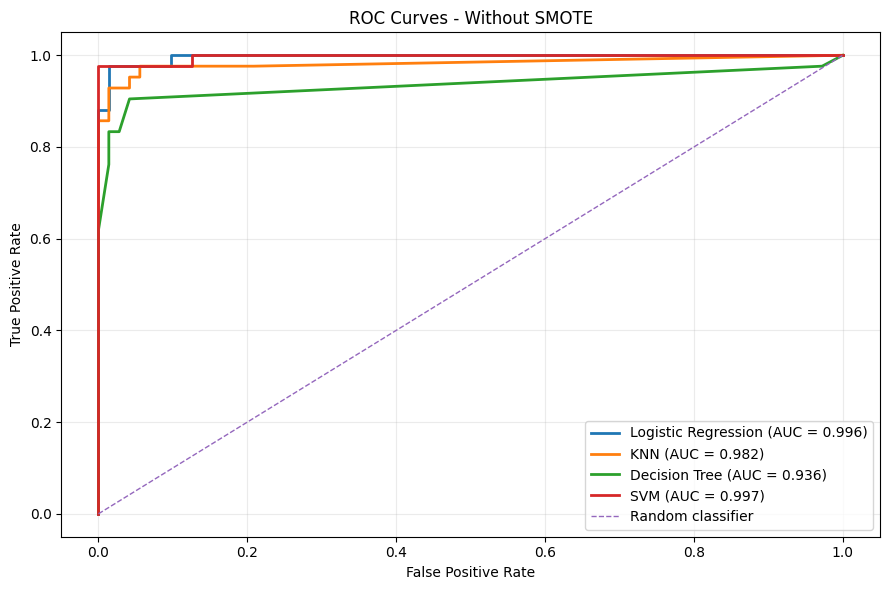

In [10]:
plt.figure(figsize=(9, 6))
for model_name in model_specs:
    key = f"Without SMOTE - {model_name}"
    values = roc_data[key]
    plt.plot(
        values["fpr"],
        values["tpr"],
        linewidth=2,
        label=f'{model_name} (AUC = {values["auc"]:.3f})',
    )

plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Without SMOTE")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. ROC-AUC curves with SMOTE

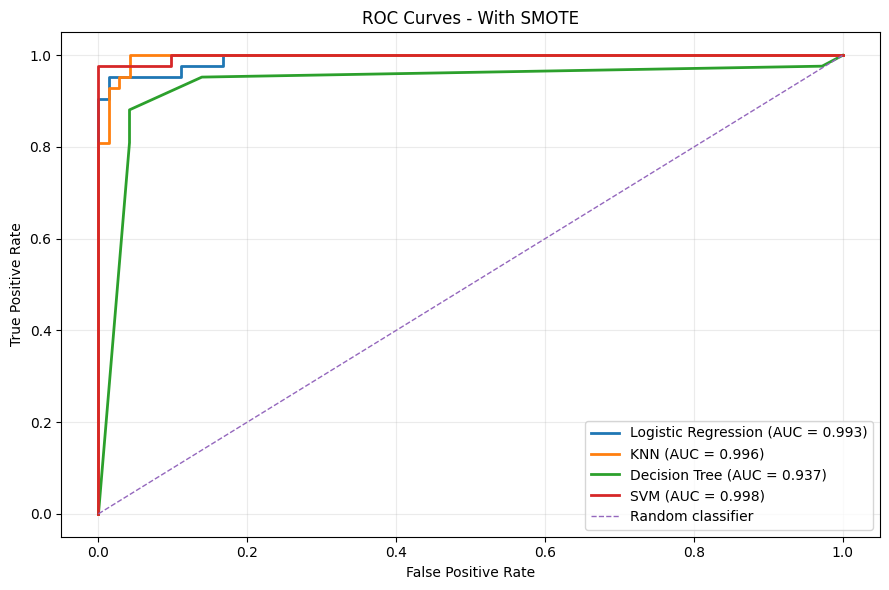

In [11]:
plt.figure(figsize=(9, 6))
for model_name in model_specs:
    key = f"With SMOTE - {model_name}"
    values = roc_data[key]
    plt.plot(
        values["fpr"],
        values["tpr"],
        linewidth=2,
        label=f'{model_name} (AUC = {values["auc"]:.3f})',
    )

plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - With SMOTE")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Direct comparison of test ROC-AUC

Scenario,Without SMOTE,With SMOTE
Model,,
Logistic Regression,0.9964,0.9927
KNN,0.9823,0.9957
Decision Tree,0.9358,0.9370
SVM,0.9970,0.9977


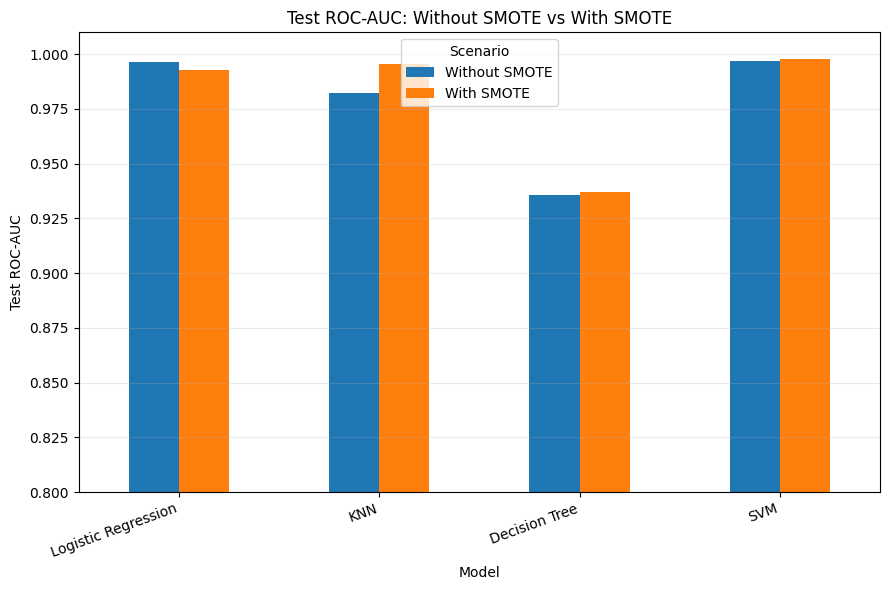

In [12]:
auc_pivot = results_df.pivot(index="Model", columns="Scenario", values="Test ROC-AUC")
auc_pivot = auc_pivot.reindex(list(model_specs.keys()))

display(auc_pivot.style.format("{:.4f}"))

ax = auc_pivot.plot(kind="bar", figsize=(9, 6), ylim=(0.80, 1.01))
ax.set_title("Test ROC-AUC: Without SMOTE vs With SMOTE")
ax.set_xlabel("Model")
ax.set_ylabel("Test ROC-AUC")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Recommended model: SVM without SMOTE

The model is selected using the full evidence rather than choosing only the largest single test AUC. The non-SMOTE RBF SVM has excellent cross-validated AUC, excellent test AUC, the highest overall test accuracy, perfect malignant precision and benign specificity, and only one false negative.

The SMOTE SVM has a tiny test-AUC increase, but its malignant recall falls because it misses three malignant cases instead of one. Since the original class imbalance is moderate rather than extreme, the synthetic oversampling does not provide a practical improvement here.

Recommended pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 SVC(C=10, class_weight='balanced', gamma=0.01,
                     random_state=42))])

Test ROC-AUC: 0.9970

Classification report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        72
   Malignant       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



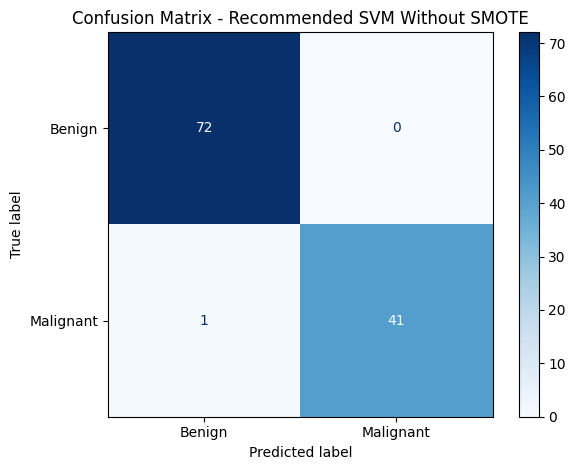

In [13]:
recommended_key = "Without SMOTE - SVM"
recommended_model = best_estimators[recommended_key]
recommended_predictions = recommended_model.predict(X_test)
recommended_scores = positive_class_scores(recommended_model, X_test)

print("Recommended pipeline:")
print(recommended_model)
print(f"\nTest ROC-AUC: {roc_auc_score(y_test, recommended_scores):.4f}")
print("\nClassification report:")
print(classification_report(
    y_test,
    recommended_predictions,
    target_names=["Benign", "Malignant"],
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    recommended_predictions,
    display_labels=["Benign", "Malignant"],
    cmap="Blues",
    values_format="d",
)
plt.title("Confusion Matrix - Recommended SVM Without SMOTE")
plt.tight_layout()
plt.show()

## 12. Interpretation of results

### Logistic Regression
Logistic Regression performed very well both with and without SMOTE. Without SMOTE, it achieved a test ROC-AUC of approximately **0.9964**, accuracy of **0.9737**, and malignant recall of **0.9524**. SMOTE did not improve its classification metrics and slightly reduced test ROC-AUC. This suggests the standardized original training data already provided enough information for the model.

### KNN
KNN benefited from SMOTE. Its test ROC-AUC improved from approximately **0.9823** to **0.9957**, and malignant recall increased from **0.8810** to **0.9286**. This makes sense because KNN is based on local neighborhoods, so additional minority-class samples can improve the representation of malignant cases. However, it still did not outperform the recommended SVM on accuracy or malignant recall.

### Decision Tree
The Decision Tree was the weakest model. Its test ROC-AUC remained around **0.936-0.937**, and malignant recall was lower than the other approaches. A single tree can be unstable and may not capture the smooth, complex relationships among the tumor measurements as effectively as Logistic Regression or SVM. SMOTE produced only a small improvement.

### SVM
SVM was the strongest overall approach. The non-SMOTE RBF SVM achieved approximately **0.9970 test ROC-AUC**, **0.9912 accuracy**, **1.0000 precision**, **0.9762 malignant recall**, and **1.0000 specificity**. Its confusion matrix contained 72 true negatives, 41 true positives, no false positives, and only one false negative.

The SMOTE SVM had a slightly higher test ROC-AUC of approximately **0.9977**, but its malignant recall fell to **0.9286**, producing three false negatives. Therefore, the very small AUC difference does not justify the loss in sensitivity.

## Final recommendation
I recommend the **RBF SVM without SMOTE** with `C=10`, `gamma=0.01`, and `class_weight='balanced'`. It provides the strongest balance of discrimination, accuracy, malignant recall, and specificity. I would not use SMOTE for the final model because it did not improve the most important practical classification results and adds synthetic observations that are unnecessary for this moderately imbalanced dataset.

## 13. Strategies to improve each model further

### Logistic Regression
- Use finer tuning around the best `C` value.
- Test interaction or polynomial terms if nonlinear relationships are expected.
- Apply feature selection to remove highly correlated or redundant measurements.
- Compare L1, L2, and elastic-net regularization using repeated cross-validation.
- Tune the probability threshold to prioritize malignant recall.

### KNN
- Search a wider and finer range of neighbor values.
- Compare alternative distance metrics and feature scalers, such as RobustScaler.
- Use PCA or feature selection because irrelevant dimensions can weaken distance-based models.
- Detect and handle outliers, which can distort nearest-neighbor relationships.
- Tune SMOTE parameters such as `k_neighbors` inside the pipeline.

### Decision Tree
- Tune cost-complexity pruning (`ccp_alpha`) and a wider range of depth and leaf-size values.
- Use repeated cross-validation because a single tree can change considerably across samples.
- Compare class weighting and threshold-sensitive evaluation.
- Use ensemble extensions such as Random Forest, Extra Trees, or Gradient Boosting to reduce variance and improve predictive power.

### SVM
- Conduct a finer grid or randomized search around `C=10` and `gamma=0.01`.
- Compare additional kernels only when justified by cross-validation.
- Use feature selection or PCA to reduce correlated inputs and training complexity.
- Tune the decision threshold to minimize false negatives.
- Calibrate decision scores if reliable probabilities are needed.

### General improvements
- Use repeated stratified or nested cross-validation for a less optimistic performance estimate.
- Evaluate precision-recall AUC in addition to ROC-AUC.
- Validate the chosen model on an independent external dataset.
- Examine feature importance or model explanations to improve interpretability.
- Select the final classification threshold based on the relative cost of false negatives and false positives.

## 14. Conclusion

All required classifiers were optimized using pipelines and `GridSearchCV`, both without and with SMOTE. Standardization was used only where feature scale matters, and SMOTE was kept inside cross-validation pipelines to prevent leakage. Based on ROC-AUC and the full set of test metrics, the **SVM without SMOTE** is the most appropriate model for this dataset.